In [20]:
import subprocess
import time

# Start MLflow server in background if not already running
mlflow_server = subprocess.Popen(
    ["uv", "run", "mlflow", "ui", "--port", "5000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)  # Give it time to start up
print("✅ MLflow server started at http://localhost:5000")

✅ MLflow server started at http://localhost:5000


In [21]:
import duckdb
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score, 
                              confusion_matrix, PrecisionRecallDisplay,
                              precision_recall_curve, average_precision_score)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Point MLflow at your local server
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("olist-churn-prediction")

print("✅ Setup complete")

✅ Setup complete


In [22]:
con = duckdb.connect('../data/olist.db')
print(f"Connected ✅")
print(con.execute("SHOW TABLES").df().to_string())

Connected ✅
                    name
0   category_translation
1              customers
2            geolocation
3            order_items
4          order_payment
5         order_payments
6          order_reviews
7                 orders
8                product
9               products
10               sellers


Number of orders that each unique customer has made.

In [23]:
query = """
WITH
  base_orders AS (
    SELECT
      customers.customer_unique_id,
      orders.order_id,
      orders.order_purchase_timestamp,
      DATEDIFF (
        'day',
        order_delivered_customer_date,
        order_estimated_delivery_date
      ) AS delivery_delay
    FROM
      customers
      LEFT JOIN orders ON customers.customer_id = orders.customer_id
    WHERE
      orders.order_status = 'delivered'
  ),
  customer_metrics AS (
    SELECT
      base_orders.customer_unique_id,
      COUNT(DISTINCT base_orders.order_id) AS total_orders,
      SUM(order_items.price + order_items.freight_value) AS total_spent,
      AVG(order_items.price + order_items.freight_value) AS avg_order_value,
      MIN(base_orders.order_purchase_timestamp) AS first_order_date,
      MAX(base_orders.order_purchase_timestamp) AS last_order_date,
      COUNT(DISTINCT order_items.product_id) AS unique_product_bought,
      COUNT(DISTINCT order_items.seller_id) AS unique_sellers_used,
      AVG(order_items.freight_value / (order_items.price + order_items.freight_value)) AS freight_ratio,
      MODE() WITHIN GROUP (ORDER BY DAYOFWEEK(base_orders.order_purchase_timestamp)) as purchase_dayofweek,
      AVG(
        CASE
          WHEN delivery_delay > 0 THEN 1.0
          ELSE 0
        END
      ) AS late_delivery_rate,
      AVG(delivery_delay) AS avg_delivery_delay_days
    FROM
      base_orders
      LEFT JOIN order_items ON base_orders.order_id = order_items.order_id
    GROUP BY
      base_orders.customer_unique_id
  ),
  review_metrics AS (
    SELECT
      base_orders.customer_unique_id,
      AVG(order_reviews.review_score) AS avg_review_score
    FROM
      base_orders
      LEFT JOIN order_reviews ON base_orders.order_id = order_reviews.order_id
    GROUP BY
      base_orders.customer_unique_id
  ),
  payment_metrics AS (
    SELECT
      base_orders.customer_unique_id,
      AVG(order_payments.payment_installments) AS avg_installments,
      COUNT(DISTINCT order_payments.payment_type) as payment_types_used
    FROM
      base_orders
      LEFT JOIN order_payments ON order_payments.order_id = base_orders.order_id
    GROUP BY
      base_orders.customer_unique_id
  ),
  final_metrics AS (
    SELECT
      customer_metrics.customer_unique_id,
      customer_metrics.total_orders,
      customer_metrics.total_spent,
      customer_metrics.freight_ratio,
      customer_metrics.avg_order_value,
      customer_metrics.first_order_date,
      customer_metrics.last_order_date,
      customer_metrics.unique_product_bought,
      customer_metrics.unique_sellers_used,
      customer_metrics.late_delivery_rate,
      customer_metrics.avg_delivery_delay_days,
      customer_metrics.purchase_dayofweek,
      review_metrics.avg_review_score,
      payment_metrics.avg_installments,
      payment_metrics.payment_types_used,
      DATEDIFF (
        'day',
        last_order_date,
        (
          SELECT
            MAX(orders.order_purchase_timestamp)
          FROM
            orders
        )
      ) AS recency_days,
      DATEDIFF (
        'day',
        customer_metrics.first_order_date,
        customer_metrics.last_order_date
      ) AS customer_lifespan_days
    FROM
      customer_metrics
      LEFT JOIN review_metrics ON review_metrics.customer_unique_id = customer_metrics.customer_unique_id
      LEFT JOIN payment_metrics ON payment_metrics.customer_unique_id = customer_metrics.customer_unique_id
  )
SELECT
  *,
  CASE
    WHEN recency_days > 90 THEN 1
    ELSE 0
  END AS churned
FROM
  final_metrics
"""

df = con.execute(query).df()

print(f"Dataset shape:      {df.shape}")
print(f"Churn rate:         {df['churned'].mean():.2%}")
print(f"Churned:            {df['churned'].sum():,}")
print(f"Not churned:        {(df['churned']==0).sum():,}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nSample:")
df.head()

Dataset shape:      (93358, 18)
Churn rate:         89.98%
Churned:            83,999
Not churned:        9,359

Missing values:
customer_unique_id           0
total_orders                 0
total_spent                  0
freight_ratio                0
avg_order_value              0
first_order_date             0
last_order_date              0
unique_product_bought        0
unique_sellers_used          0
late_delivery_rate           0
avg_delivery_delay_days      8
purchase_dayofweek           0
avg_review_score           603
avg_installments             1
payment_types_used           0
recency_days                 0
customer_lifespan_days       0
churned                      0
dtype: int64

Sample:


,customer_unique_id,total_orders,total_spent,freight_ratio,avg_order_value,first_order_date,last_order_date,unique_product_bought,unique_sellers_used,late_delivery_rate,avg_delivery_delay_days,purchase_dayofweek,avg_review_score,avg_installments,payment_types_used,recency_days,customer_lifespan_days,churned
0,fa78b26c2fa23b2ebda98c2926305c1d,1,419.39,0.070078,419.39,2018-07-08 09:17:59,2018-07-08 09:17:59,1,1,1.0,3.0,0,5.0,7.0,1,101,0,1
1,2e875ea57961ad115cec13fef0920ae6,1,93.62,0.460610,46.81,2017-08-04 09:19:10,2017-08-04 09:19:10,2,2,1.0,29.0,5,5.0,9.0,1,439,0,1
2,b7eccb8247dce2f986bc667143eb475e,1,157.34,0.136265,157.34,2017-07-10 20:42:56,2017-07-10 20:42:56,1,1,1.0,18.0,1,5.0,1.0,1,464,0,1
3,0124721bc33e0aa6772b42d4ccfd01db,1,100.33,0.152895,100.33,2017-06-14 09:44:30,2017-06-14 09:44:30,1,1,1.0,3.0,3,4.0,1.0,1,490,0,1
4,14b1fe83a6c8579f0502b467afe01b7c,1,84.69,0.185264,84.69,2017-04-23 23:28:23,2017-04-23 23:28:23,1,1,1.0,13.0,0,5.0,8.0,1,542,0,1


In [24]:
# In this cell we are doing some pre-processing. 

# 1. Droping the customer_unique_id, first_order_date, last_order_date
df = df.drop(columns=['customer_unique_id', 'first_order_date', 'last_order_date', 'recency_days'])

# 2. dropping the missing 
df = df[~df['avg_installments'].isnull()]
df = df[~df['avg_review_score'].isnull()]
df = df[~df['avg_delivery_delay_days'].isnull()]


# 3. Defining Feature cols
feature_cols = df.columns.drop('churned')
X = df[feature_cols]
y = df['churned']

# 4. Train / Test Split - stratified, 80/20, random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Smote for training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [25]:
# Training the Random Forest Algorithm

rf_params = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_leaf": 20,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

with mlflow.start_run(run_name="RandomForest_v2"):

    # 1. Train
    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train_bal, y_train_bal)

    # 2. Predict
    y_pred = rf_model.predict(X_test)
    y_proba = rf_model.predict_proba(X_test)[:, 1]

    # 3. Score
    roc_auc = roc_auc_score(y_test, y_proba)

    # 4. Log to MLflow
    mlflow.log_params(rf_params)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.sklearn.log_model(rf_model, "random_forest_model")

    print(f"ROC-AUC-RF: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

2026/05/17 10:00:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/17 10:00:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/17 10:00:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


ROC-AUC-RF: 0.7058
              precision    recall  f1-score   support

           0       0.24      0.46      0.31      1864
           1       0.93      0.84      0.88     16686

    accuracy                           0.80     18550
   macro avg       0.59      0.65      0.60     18550
weighted avg       0.86      0.80      0.82     18550

🏃 View run RandomForest_v2 at: http://localhost:5000/#/experiments/1/runs/581268f311c844de8559fb5067a896a1
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [30]:
xgb_params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 1,
    "random_state": 42,
}

with mlflow.start_run(run_name="XGBoost_v2.2"):

    # 1. Train
    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train)

    # 2. Predict
    y_pred = xgb_model.predict(X_test)
    y_proba = xgb_model.predict_proba(X_test)[:, 1]

    # 3. Score
    roc_auc = roc_auc_score(y_test, y_proba)

    # 4. Log to MLflow
    mlflow.log_params(xgb_params)
    mlflow.log_metric("roc-auc", roc_auc)
    mlflow.sklearn.log_model(xgb_model, "xgboost_model")

    print(f"ROC-AUC-XGB: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

2026/05/17 10:24:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/17 10:24:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/17 10:24:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


ROC-AUC-XGB: 0.7667
              precision    recall  f1-score   support

           0       0.70      0.06      0.10      1864
           1       0.90      1.00      0.95     16686

    accuracy                           0.90     18550
   macro avg       0.80      0.53      0.53     18550
weighted avg       0.88      0.90      0.86     18550

🏃 View run XGBoost_v2.2 at: http://localhost:5000/#/experiments/1/runs/fe6e48a352b74829a85ef65cbea6bc21
🧪 View experiment at: http://localhost:5000/#/experiments/1


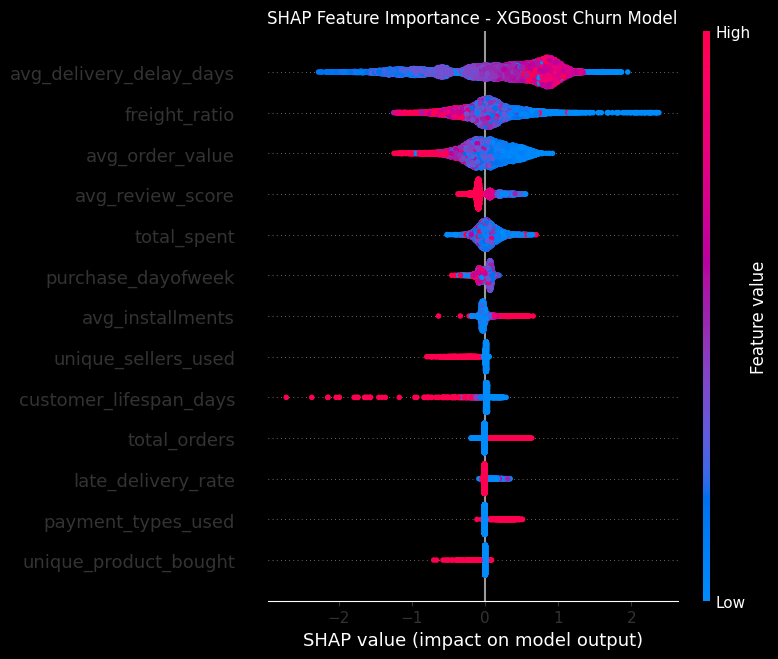

In [31]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance - XGBoost Churn Model')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()